In [12]:
import numpy as np
import matplotlib.pyplot as plt

In [13]:
# initialize the rolling and the sum for each of the 3 rolls
roll = [(d1,d2,d3) for d1 in range(1,7)
                    for d2 in range(1,7)
                    for d3 in range(1,7)]
sums = [sum(r) for r in roll]

In [14]:
# consider all possible scores 3-18
# counts scores number of microstates that produce each total score s
scores = np.arange(3,19)
counts = np.array([sums.count(s) for s in scores])

In [15]:
# Convert multiplicity to probability
prob = counts / 216
# Microstate entropy per score
entropy = np.log(counts)

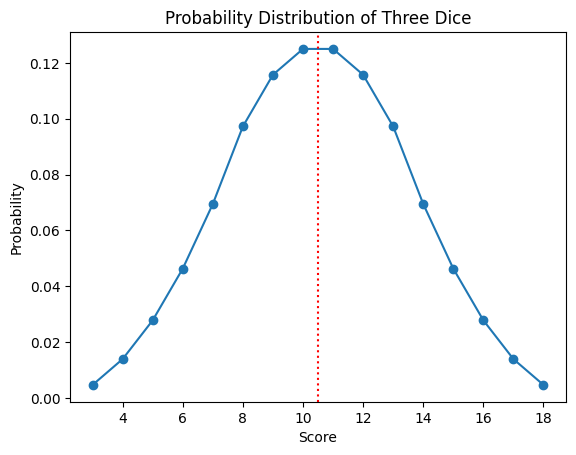

In [20]:
# plot probablility distribution
plt.plot(scores, prob, 'o-')
plt.xlabel("Score")
plt.ylabel("Probability")
plt.title("Probability Distribution of Three Dice")
plt.axvline(x=10.5, color='r', linestyle=':')
plt.show()

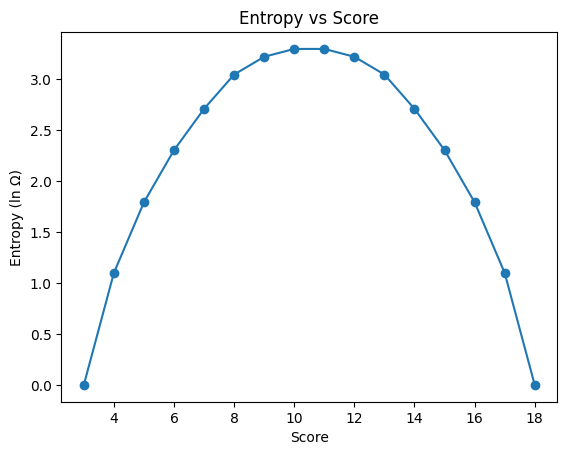

In [23]:
# plot entropy (boltzmann)
plt.figure()
plt.plot(scores, entropy, marker='o')
plt.xlabel("Score")
plt.ylabel("Entropy (ln Ω)")
plt.title("Entropy vs Score")
plt.show()

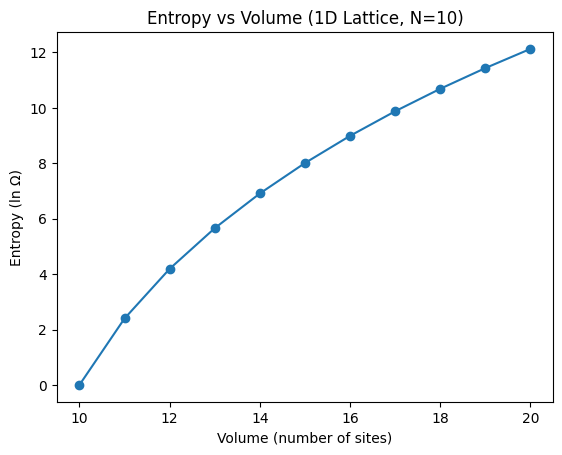

In [24]:
import numpy as np
import matplotlib.pyplot as plt
import math

N = 10
V_values = range(10, 21)

entropy = []

for V in V_values:
    omega = math.comb(V, N)      # binomial coefficient
    S = math.log(omega)          # entropy = ln Ω
    entropy.append(S)

# Plot
plt.plot(V_values, entropy, marker='o')
plt.xlabel("Volume (number of sites)")
plt.ylabel("Entropy (ln Ω)")
plt.title("Entropy vs Volume (1D Lattice, N=10)")
plt.show()


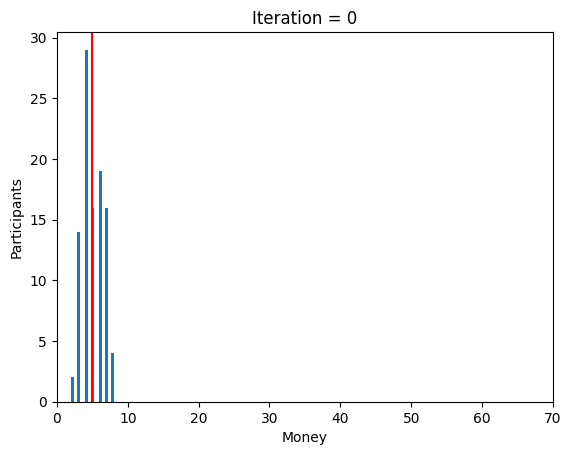

<Figure size 640x480 with 0 Axes>

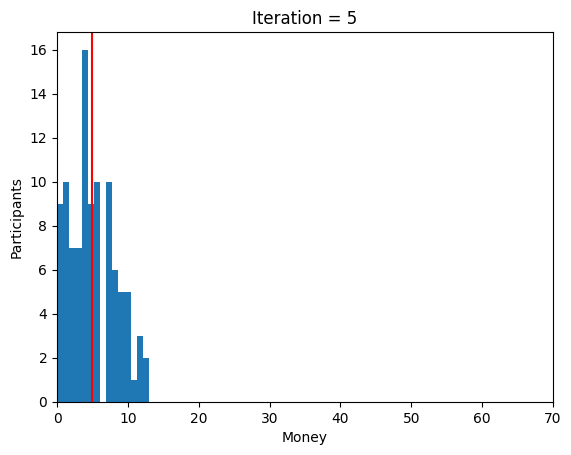

<Figure size 640x480 with 0 Axes>

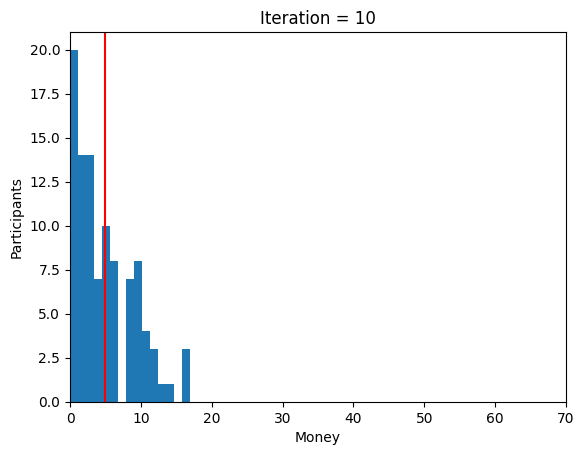

<Figure size 640x480 with 0 Axes>

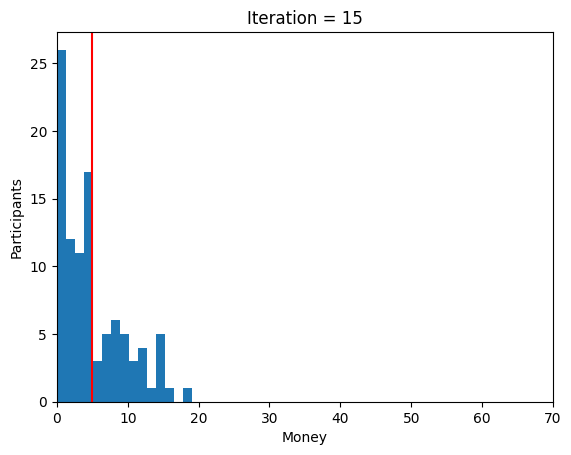

<Figure size 640x480 with 0 Axes>

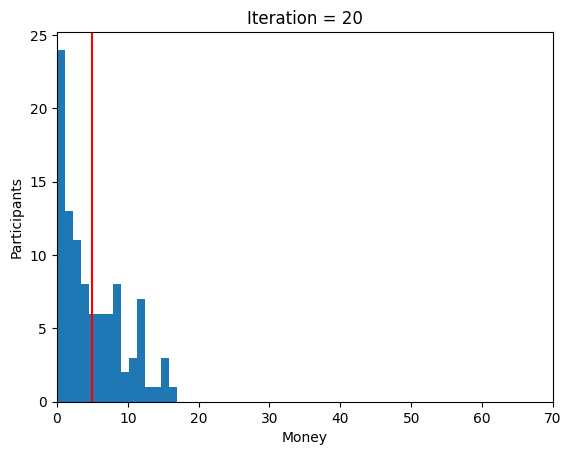

<Figure size 640x480 with 0 Axes>

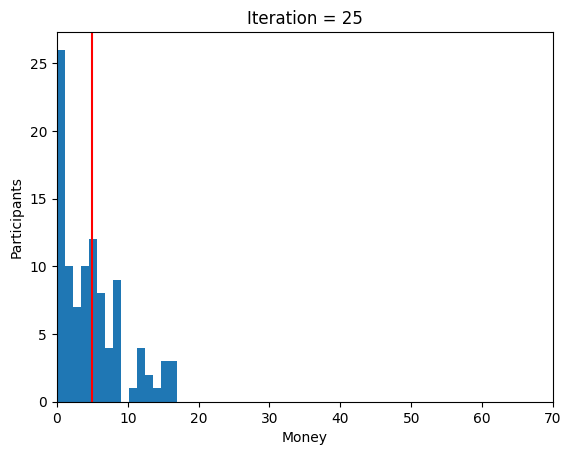

<Figure size 640x480 with 0 Axes>

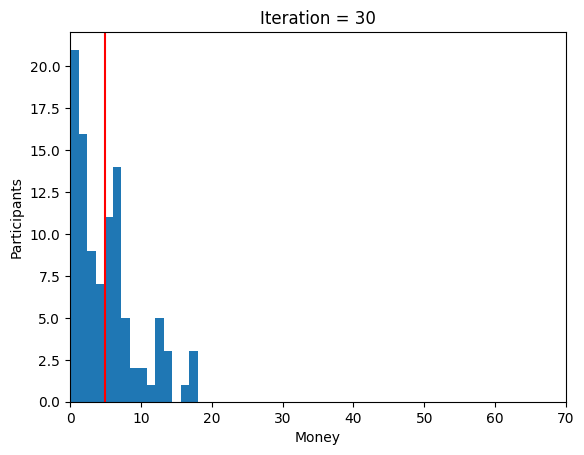

<Figure size 640x480 with 0 Axes>

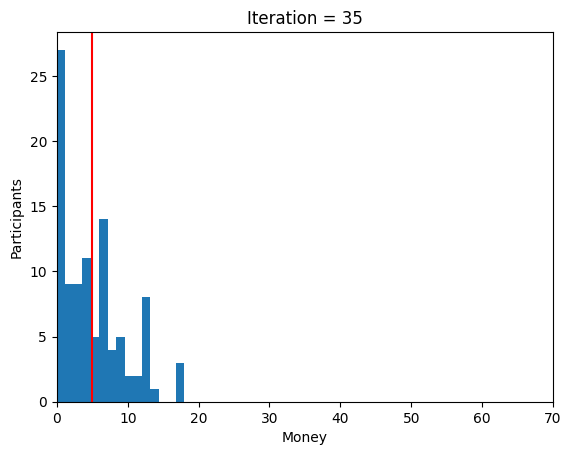

<Figure size 640x480 with 0 Axes>

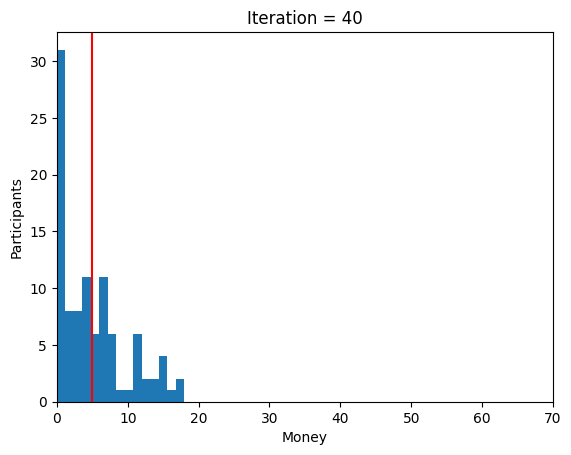

<Figure size 640x480 with 0 Axes>

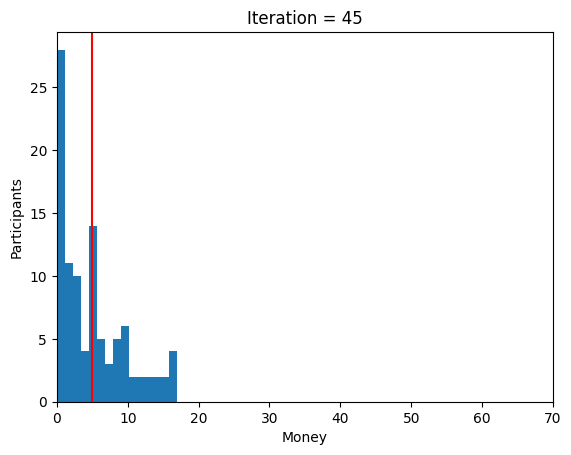

<Figure size 640x480 with 0 Axes>

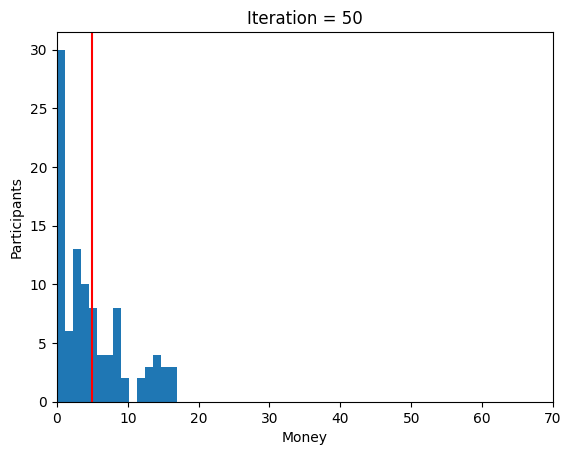

<Figure size 640x480 with 0 Axes>

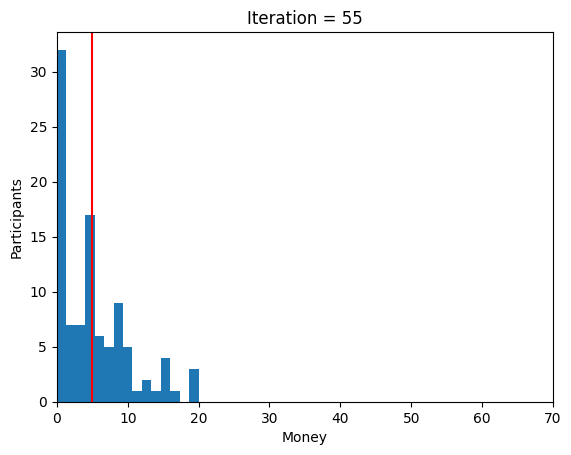

<Figure size 640x480 with 0 Axes>

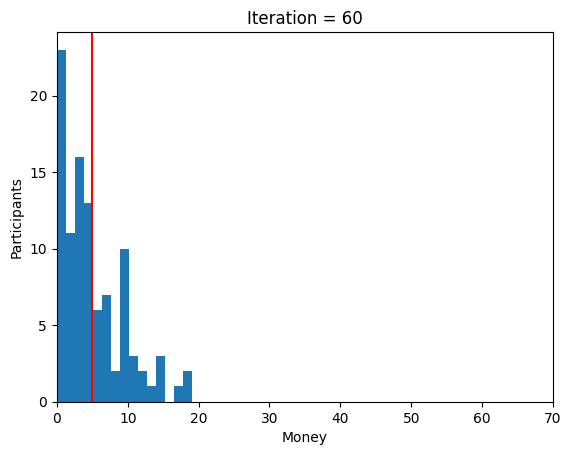

<Figure size 640x480 with 0 Axes>

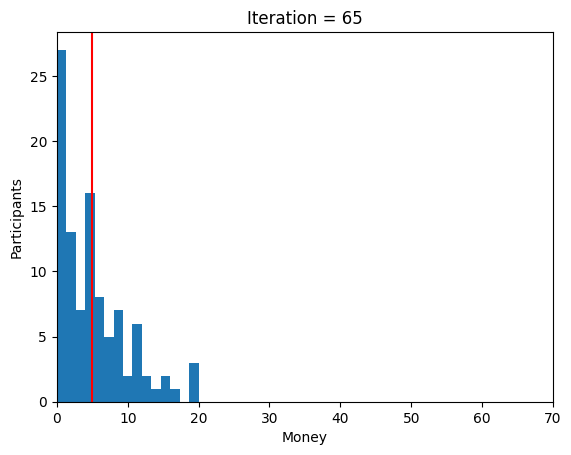

<Figure size 640x480 with 0 Axes>

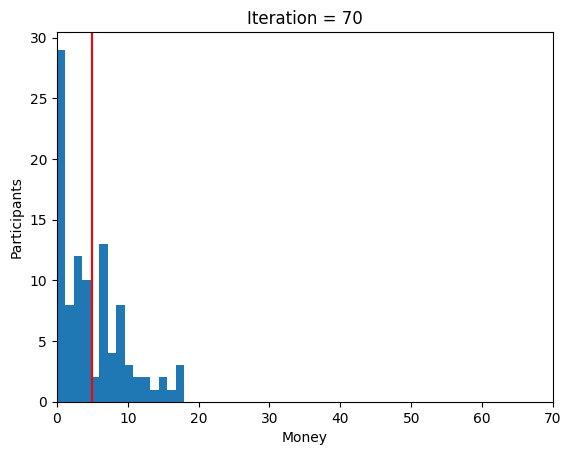

<Figure size 640x480 with 0 Axes>

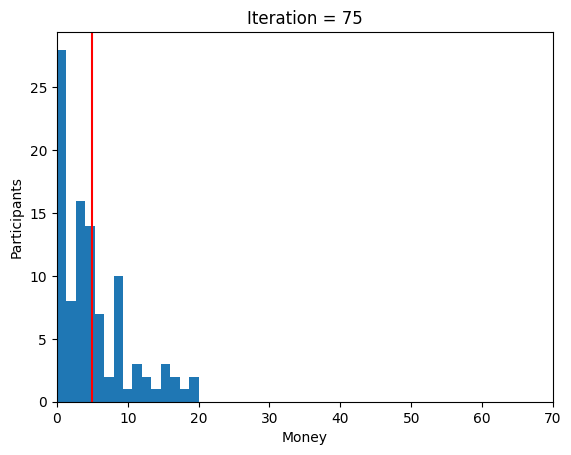

<Figure size 640x480 with 0 Axes>

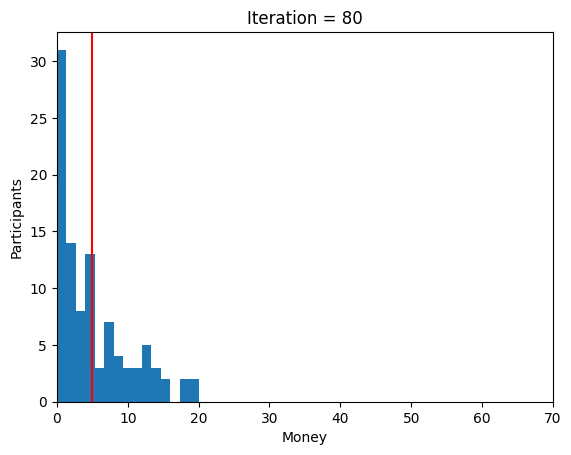

<Figure size 640x480 with 0 Axes>

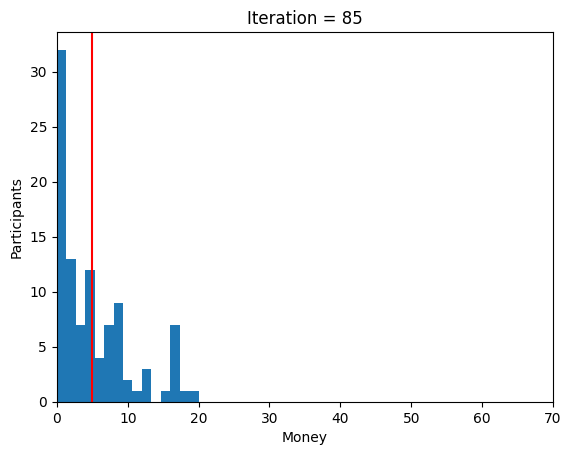

<Figure size 640x480 with 0 Axes>

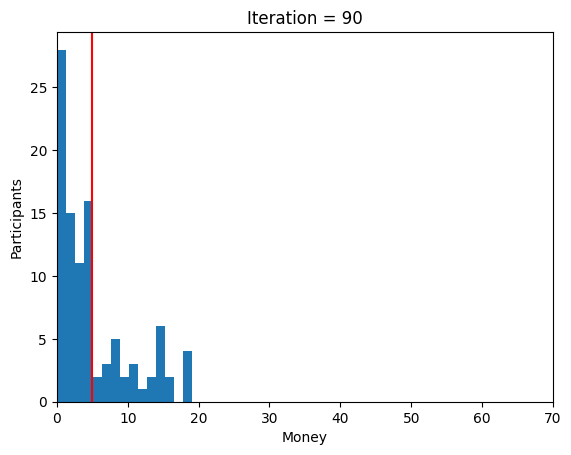

<Figure size 640x480 with 0 Axes>

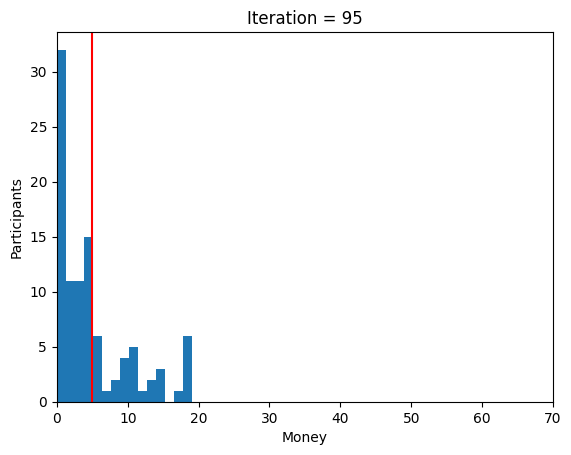

<Figure size 640x480 with 0 Axes>

In [31]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
NumInd = 100  # number of individuals
InitialMoney = 5  # amount of money for each individual
NumIter = 100  # number of iterations
UpperBound = 20  # maximum amount of money any individual can have
NumSimulations = 50  
PlayerCounts = [10, 20, 50, 100, 200, 500]

# Initialize the vector and fund the individuals
IndVec = np.zeros(NumInd) + InitialMoney

for q in range(NumIter):
    for n in range(NumInd):
        
        # Pick a random person
        PartnerInd = np.random.randint(0, NumInd)
        
        # Exchange type (give money, accept money, no action)
        action = np.random.randint(0, 2)
        
        # If individual has money, perform exchange
        if action == 0:  # give money
            if IndVec[n] > 0 and IndVec[PartnerInd] < UpperBound:
                IndVec[n] -= 1
                IndVec[PartnerInd] += 1
        
        if action == 1:  # receive money
            if IndVec[PartnerInd] > 0 and IndVec[n] < UpperBound:
                IndVec[n] += 1
                IndVec[PartnerInd] -= 1
    
    # Plot the distribution every 5th iteration
    if q == 0 or q % 5 == 0:
        plt.figure(6)
        plt.hist(IndVec, bins=15)
        plt.xlabel('Money')
        plt.ylabel('Participants')
        plt.xlim(0, 70)
        plt.axvline(x=InitialMoney, color='r')
        plt.title('Iteration = {}'.format(q))
        plt.draw()
        plt.pause(0.5)
        plt.clf()

plt.show()

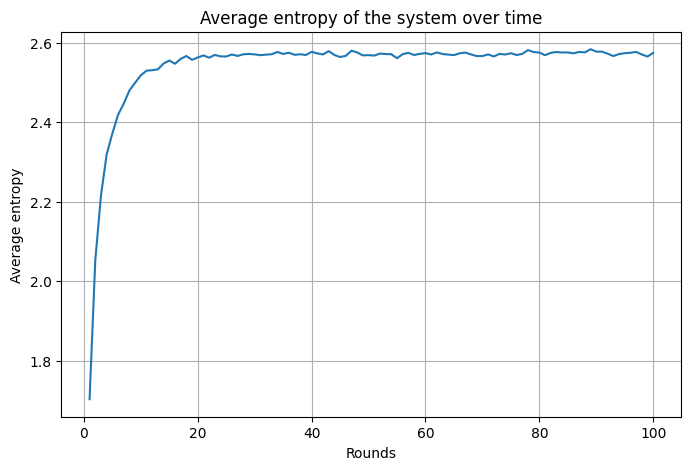

In [30]:
AvgEntropy = np.zeros(NumIter)

for sim in range(NumSimulations):
    # Initialize money
    IndVec = np.zeros(NumInd) + InitialMoney
    
    EntropyHistory = []
    
    for q in range(NumIter):
        for n in range(NumInd):
            PartnerInd = np.random.randint(0, NumInd)
            action = np.random.randint(0, 2)
            
            if action == 0:  # give money
                if IndVec[n] > 0 and IndVec[PartnerInd] < UpperBound:
                    IndVec[n] -= 1
                    IndVec[PartnerInd] += 1
            else:  # receive money
                if IndVec[PartnerInd] > 0 and IndVec[n] < UpperBound:
                    IndVec[n] += 1
                    IndVec[PartnerInd] -= 1
        
        # Compute probability distribution
        values, counts = np.unique(IndVec, return_counts=True)
        probs = counts / NumInd
        
        # Shannon entropy
        entropy = -np.sum(probs * np.log(probs))
        EntropyHistory.append(entropy)
    
    AvgEntropy += np.array(EntropyHistory)

# Average over simulations
AvgEntropy /= NumSimulations

# Plot
plt.figure(figsize=(8,5))
plt.plot(range(1, NumIter+1), AvgEntropy)
plt.xlabel("Rounds")
plt.ylabel("Average entropy")
plt.title("Average entropy of the system over time")
plt.grid(True)
plt.show()


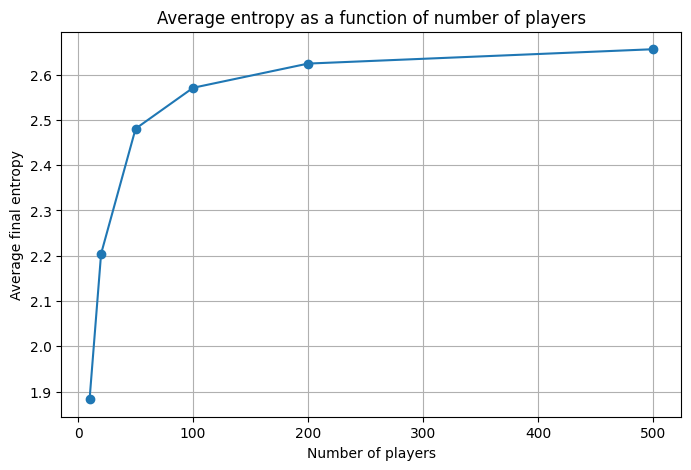

In [32]:
AvgFinalEntropy = []

for NumInd in PlayerCounts:
    EntropySum = 0
    
    for sim in range(NumSimulations):
        # Initialize money
        IndVec = np.zeros(NumInd) + InitialMoney
        
        for q in range(NumIter):
            for n in range(NumInd):
                PartnerInd = np.random.randint(0, NumInd)
                action = np.random.randint(0, 2)
                
                if action == 0:  # give money
                    if IndVec[n] > 0 and IndVec[PartnerInd] < UpperBound:
                        IndVec[n] -= 1
                        IndVec[PartnerInd] += 1
                else:  # receive money
                    if IndVec[PartnerInd] > 0 and IndVec[n] < UpperBound:
                        IndVec[n] += 1
                        IndVec[PartnerInd] -= 1
        
        # Compute probability distribution
        values, counts = np.unique(IndVec, return_counts=True)
        probs = counts / NumInd
        entropy = -np.sum(probs * np.log(probs))
        
        EntropySum += entropy
    
    AvgFinalEntropy.append(EntropySum / NumSimulations)

# Plot
plt.figure(figsize=(8,5))
plt.plot(PlayerCounts, AvgFinalEntropy, marker='o')
plt.xlabel("Number of players")
plt.ylabel("Average final entropy")
plt.title("Average entropy as a function of number of players")
plt.grid(True)
plt.show()


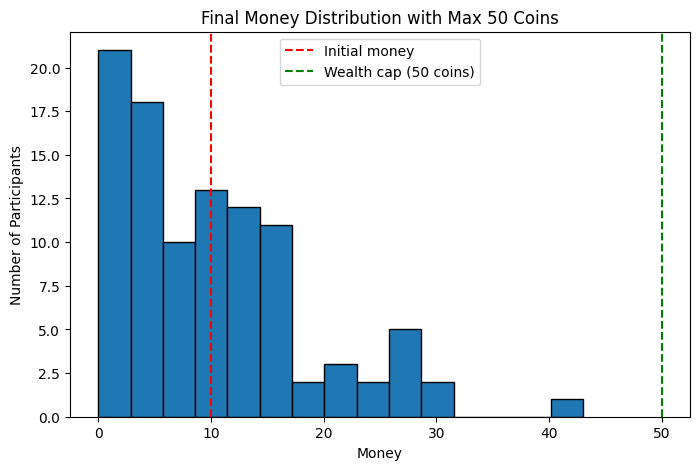

In [33]:
import numpy as np
import matplotlib.pyplot as plt

# Parameters
NumInd = 100        # number of individuals
InitialMoney = 10   # starting money for each individual
NumIter = 100       # number of iterations
UpperBound = 50     # maximum money any individual can have

# Initialize money
IndVec = np.zeros(NumInd) + InitialMoney

# Run simulation
for q in range(NumIter):
    for n in range(NumInd):
        # Pick a random partner
        PartnerInd = np.random.randint(0, NumInd)
        
        # Random action: give or receive
        action = np.random.randint(0, 2)
        
        if action == 0:  # give money
            if IndVec[n] > 0 and IndVec[PartnerInd] < UpperBound:
                IndVec[n] -= 1
                IndVec[PartnerInd] += 1
        else:  # receive money
            if IndVec[PartnerInd] > 0 and IndVec[n] < UpperBound:
                IndVec[n] += 1
                IndVec[PartnerInd] -= 1

# Plot final distribution
plt.figure(figsize=(8,5))
plt.hist(IndVec, bins=15, edgecolor='black')
plt.xlabel('Money')
plt.ylabel('Number of Participants')
plt.title('Final Money Distribution with Max 50 Coins')
plt.axvline(x=InitialMoney, color='r', linestyle='--', label='Initial money')
plt.axvline(x=UpperBound, color='g', linestyle='--', label='Wealth cap (50 coins)')
plt.legend()
plt.show()
